In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch.nn as nn

from src import (
    load_experiment, get_transform, get_loaders_from_config,
    collect_layer_inputs, collect_layer_inputs_generic,
    bft, evaluate,
    extract_tree_nodes, compute_node_activations, plot_factor_tree,
    extract_factor_fingerprint, extract_fingerprint_matrix,
    compute_stimulus_similarity, project_stimuli_onto_tree,
    extract_factor_tree_nodes, compute_factor_activations,
    nodes_at_layer, top_stimuli_factor_activations,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
matplotlib.rcParams.update({"figure.dpi": 80})


device: cuda


# Notebook 07: Stimulus-Conditioned BFT Factor Analysis — Digit MLP 40-20

Same analysis pipeline as Notebook 06, applied to the **10-class digit classifier**
(SimpleMLP 784→40→20→10, trained on all MNIST digits 0–9).

**Key differences from Notebook 06:**
- Identity label transform: classes are the 10 digits directly (no even/odd collapsing).
- All 10 MNIST digits appear in training — no excluded digits to use as near-OOD.
- **Real OOD = Fashion-MNIST**: same 28×28 grayscale format, completely different visual domain.

**Section 2** — Factor tree visualisation per output/input factor.

**Section 3** — Factor fingerprints & pairwise stimulus similarity.

**Section 4** — ID sanity check: train vs. test (same digit distribution).

**Section 5** — Real OOD: Fashion-MNIST items projected onto fixed BFT factors.

**Section 5b** — Far OOD: synthetic images (noise, gray, checkerboard, inverted).

## Section 1: Setup — load model, data, run BFT

In [2]:
EXPERIMENT_DIR = '../experiments/mnist_digit_mlp_40_20_seed0'
# Forward order (L0=784→40, L1=40→20, L2=20→10)
N_BRANCHES     = [1, 2, 5]    # 5 branches at output layer, 2 at middle, leaf at input
K_MAX          = [10, 6, 10]  # up to 10 factors at output (one per class)
STIM_THRESHOLD = 0.7
AUTO_THRESHOLD = 0.70
TOP_N_FACTOR   = 50

model, cfg = load_experiment(EXPERIMENT_DIR, device)
train_loader, test_loader = get_loaders_from_config(cfg)
label_transform = get_transform(cfg['label_transform'])  # None for 'identity'

CLASS_NAMES = {i: str(i) for i in range(cfg['arch_kwargs']['output_dim'])}
IMAGE_SIDE  = cfg['input_side']

# Fashion-MNIST class names (the real OOD domain)
FMNIST_CLASSES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot',
]

_, test_acc = evaluate(model, test_loader,
                       criterion=nn.CrossEntropyLoss(),
                       label_transform=label_transform, device=device)
print(f'Test accuracy : {test_acc:.4f}')
print(f'Classes       : {CLASS_NAMES}')
print(f'Image side    : {IMAGE_SIDE}')
print(f'OOD domain    : Fashion-MNIST (28×28 grayscale, 10 fashion categories)')
_nb_dir   = os.path.dirname(os.path.abspath('__file__'))
_repo_dir = os.path.dirname(_nb_dir)
FIG_DIR   = os.path.join(_repo_dir, 'figs', '07_digit_stimulus_analysis')
os.makedirs(FIG_DIR, exist_ok=True)
print(f'FIG_DIR: {FIG_DIR}')


Test accuracy : 0.9347
Classes       : {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9'}
Image side    : 28
OOD domain    : Fashion-MNIST (28×28 grayscale, 10 fashion categories)
FIG_DIR: /home/jb3879/Factor_Trace/figs/07_digit_stimulus_analysis


In [3]:
data_test = collect_layer_inputs(
    model, test_loader.dataset,
    label_transform=label_transform, n_per_class=None, device=device,
)
idx = np.random.choice(len(data_test['images']), 1000, replace=False)
all_images   = data_test['images'][idx]       # (N, 1, 28, 28)
all_targets  = data_test['targets'][idx]       # (N,) digit 0–9
all_digits   = data_test['digits'][idx]        # same as all_targets for identity transform
layer_inputs = [layer[idx] for layer in data_test['layer_inputs']]  # list[(N, n_in)] forward order
n_samples    = len(all_images)
print(f'Test samples : {n_samples}')
print(f'Class dist   : {dict(zip(*np.unique(all_targets, return_counts=True)))}')

Test samples : 1000
Class dist   : {np.int64(0): np.int64(86), np.int64(1): np.int64(102), np.int64(2): np.int64(105), np.int64(3): np.int64(102), np.int64(4): np.int64(109), np.int64(5): np.int64(74), np.int64(6): np.int64(101), np.int64(7): np.int64(114), np.int64(8): np.int64(100), np.int64(9): np.int64(107)}


In [4]:
tree_root = bft(
    model, layer_inputs,
    k_max=K_MAX, n_branches=N_BRANCHES,
    stimulus_threshold=STIM_THRESHOLD,
    weighting='img_selectivity', verbose=1,
)

tree_nodes   = extract_tree_nodes(tree_root)
factor_nodes = extract_factor_tree_nodes(tree_root)

max_layer_idx = max(e['layer_idx'] for e in tree_nodes)
root_bft_node = tree_root
l0_nodes      = nodes_at_layer(tree_root, 0)

print(f'\nTree: {len(tree_nodes)} path nodes,  {len(factor_nodes)} factor nodes,  max_layer_idx={max_layer_idx}')
print(f'Root factors (output layer): K={len(root_bft_node["lambdas"])}')
print(f'L0 leaf nodes: {len(l0_nodes)}')
for ln in l0_nodes:
    print(f'  path={ln["path"]}  K={len(ln["lambdas"])}')

[BFT] Layer 3/3 '2' (fc)  path=[]


[BFT] Layer 2/3 '1' (fc)  path=[0]
[BFT] Layer 1/3 '0' (fc)  path=[0, 0]
[BFT] Layer 1/3 '0' (fc)  path=[0, 1]
[BFT] Layer 2/3 '1' (fc)  path=[1]
[BFT] Layer 1/3 '0' (fc)  path=[1, 0]
[BFT] Layer 1/3 '0' (fc)  path=[1, 1]
[BFT] Layer 2/3 '1' (fc)  path=[2]
[BFT] Layer 1/3 '0' (fc)  path=[2, 0]
[BFT] Layer 1/3 '0' (fc)  path=[2, 1]
[BFT] Layer 2/3 '1' (fc)  path=[3]
[BFT] Layer 1/3 '0' (fc)  path=[3, 0]
[BFT] Layer 1/3 '0' (fc)  path=[3, 1]
[BFT] Layer 2/3 '1' (fc)  path=[4]
[BFT] Layer 1/3 '0' (fc)  path=[4, 0]
[BFT] Layer 1/3 '0' (fc)  path=[4, 1]

Tree: 16 path nodes,  140 factor nodes,  max_layer_idx=2
Root factors (output layer): K=10
L0 leaf nodes: 10
  path=[0, 0]  K=10
  path=[0, 1]  K=10
  path=[1, 0]  K=10
  path=[1, 1]  K=10
  path=[2, 0]  K=10
  path=[2, 1]  K=10
  path=[3, 0]  K=10
  path=[3, 1]  K=10
  path=[4, 0]  K=10
  path=[4, 1]  K=10


### BFT Diagnostics: Round-Trip Test & Active-Sample Fractions

**Round-trip test**: project the original NMF test-set stimuli through NNLS and compare the resulting fingerprints to the stored `img_factors`. After the normalization fix in `_joint_for_node`, the root-node cosine sim should be ≈ 1.0; any residual gap in the full fingerprint reflects deep-layer path-specificity.

**Active-sample fraction**: fraction of NMF test stimuli with `stimulus_weights_in > 0.01` at each tree node — low fractions explain why new (unweighted) stimuli project poorly onto that node's factors.

In [5]:
from sklearn.metrics.pairwise import paired_cosine_distances
N_RT = min(200, n_samples)
rng_rt = np.random.default_rng(0)
rt_sub = rng_rt.choice(n_samples, N_RT, replace=False)
rt_inputs = [l[rt_sub] for l in layer_inputs]
projected_test_rt = project_stimuli_onto_tree(tree_root, rt_inputs)
F_orig_rt = extract_fingerprint_matrix(tree_root, rt_sub)
F_rt      = extract_fingerprint_matrix(projected_test_rt, np.arange(N_RT))
rt_sims = 1.0 - paired_cosine_distances(F_orig_rt, F_rt)
print(f'Test samples: {N_RT}')
print(f'Round-trip cosine sim (full):  mean={rt_sims.mean():.4f}  std={rt_sims.std():.4f}  min={rt_sims.min():.4f}')
rt_root = 1.0 - paired_cosine_distances(
    tree_root['img_factors'][rt_sub],
    projected_test_rt['img_factors'],
)
print(f'Round-trip cosine sim (root):  mean={rt_root.mean():.4f}  std={rt_root.std():.4f}  min={rt_root.min():.4f}')
print('\nActive-sample fraction per node (sw > 0.01):')
for tn in tree_nodes:
    sw = tn['stimulus_weights_in']
    frac = (sw > 0.01).mean()
    print(f"  layer={tn['layer_idx']}  path={tn['path']}  active={frac:.3f}  sw_max={sw.max():.4f}")

Test samples: 200
Round-trip cosine sim (full):  mean=0.4752  std=0.0854  min=0.2744
Round-trip cosine sim (root):  mean=1.0000  std=0.0000  min=1.0000

Active-sample fraction per node (sw > 0.01):
  layer=2  path=[]  active=1.000  sw_max=1.0000
  layer=1  path=[0]  active=0.507  sw_max=0.5944
  layer=1  path=[1]  active=0.626  sw_max=0.6393
  layer=1  path=[2]  active=0.411  sw_max=0.9386
  layer=1  path=[3]  active=0.250  sw_max=0.8043
  layer=1  path=[4]  active=0.408  sw_max=0.9041
  layer=0  path=[0, 0]  active=0.231  sw_max=0.9577
  layer=0  path=[0, 1]  active=0.259  sw_max=0.7819
  layer=0  path=[1, 0]  active=0.183  sw_max=0.9454
  layer=0  path=[1, 1]  active=0.144  sw_max=0.9516
  layer=0  path=[2, 0]  active=0.258  sw_max=0.8893
  layer=0  path=[2, 1]  active=0.167  sw_max=0.7281
  layer=0  path=[3, 0]  active=0.223  sw_max=0.8454
  layer=0  path=[3, 1]  active=0.129  sw_max=0.6848
  layer=0  path=[4, 0]  active=0.196  sw_max=0.7167
  layer=0  path=[4, 1]  active=0.199  sw_

## Section 2: Factor Tree Visualisation — one tree per factor

- **2a** — Output (last-layer / root) factors: each corresponds to a group of digit classes.
- **2b** — Input (L0 / leaf) factors, one subplot per leaf node.

Plotting 10 output-layer factor trees ...


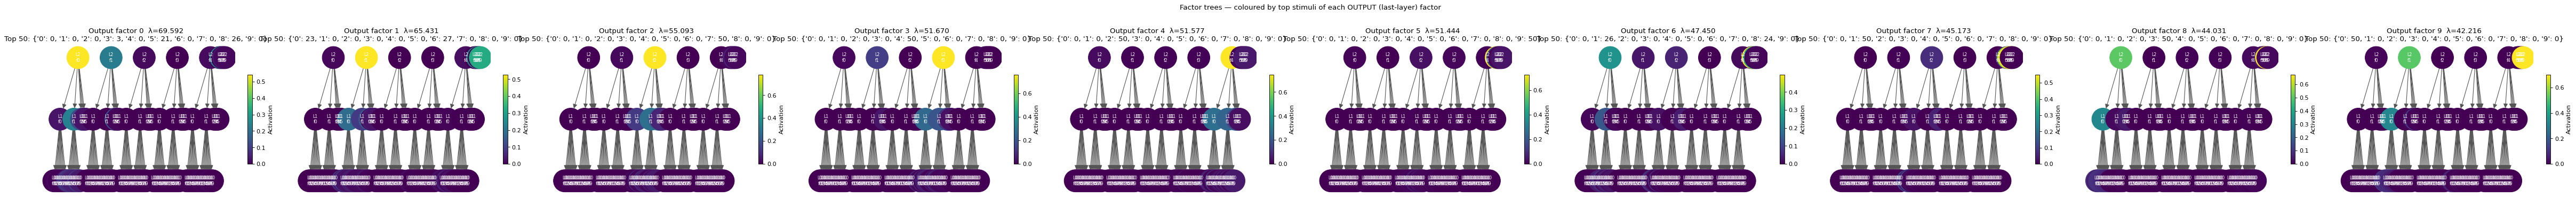

In [6]:
# ── 2a: Output (last-layer / root) factors ────────────────────────────────────
K_root = len(root_bft_node['lambdas'])
print(f'Plotting {K_root} output-layer factor trees ...')

fig, axes = plt.subplots(1, K_root, figsize=(6 * K_root, 4.5), squeeze=False)
axes = axes[0]

for k in range(K_root):
    acts, top_idx = top_stimuli_factor_activations(
        factor_nodes, root_bft_node, k, TOP_N_FACTOR
    )
    lam = root_bft_node['lambdas'][k]
    class_counts = {CLASS_NAMES[c]: int((all_targets[top_idx] == c).sum())
                    for c in sorted(np.unique(all_targets))}
    plot_factor_tree(
        factor_nodes, acts, ax=axes[k],
        title=f'Output factor {k}  λ={lam:.3f}\nTop {len(top_idx)}: {class_counts}',
    )

plt.suptitle('Factor trees — coloured by top stimuli of each OUTPUT (last-layer) factor',
             y=1.02, fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'tree_output_factors.png'), dpi=120, bbox_inches='tight')
plt.show()

## Section 3: Factor Fingerprints & Stimulus Similarity

Each stimulus is represented as the concatenation of `img_factors[s, :]` across all tree
nodes (BFS order, all K factors per node). Pairwise cosine similarity reveals how well
the factor decomposition separates digit classes.

In [7]:
F = extract_fingerprint_matrix(tree_root, np.arange(n_samples))
expected_dim = sum(len(e['lambdas']) for e in tree_nodes)
print(f'Fingerprint matrix: {F.shape}   (Σ K_i = {expected_dim})')
assert F.shape[1] == expected_dim

Fingerprint matrix: (1000, 140)   (Σ K_i = 140)


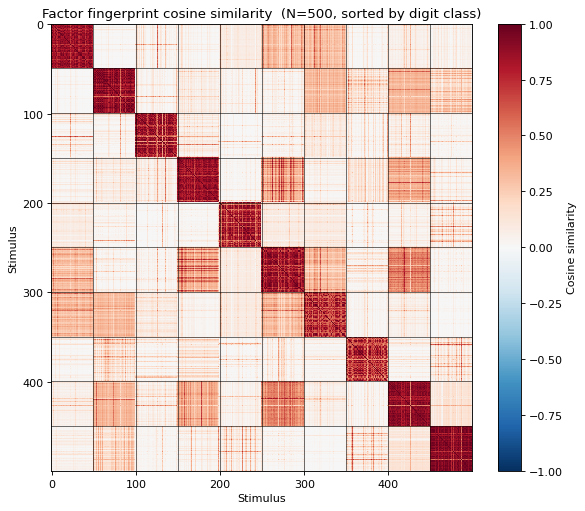

In [8]:
MAX_VIZ = 500
rng = np.random.default_rng(42)
if n_samples > MAX_VIZ:
    # Stratified sample: keep proportional representation per digit class
    viz_idx = np.concatenate([
        rng.choice(np.where(all_targets == c)[0],
                   min(MAX_VIZ // 10, (all_targets == c).sum()), replace=False)
        for c in range(10)
    ])
    viz_idx = viz_idx[np.argsort(all_targets[viz_idx])]
else:
    viz_idx = np.argsort(all_targets)

S = compute_stimulus_similarity(F[viz_idx])
targets_viz = all_targets[viz_idx]

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(S, aspect='auto', interpolation='nearest', cmap='RdBu_r', vmin=-1, vmax=1)
fig.colorbar(im, ax=ax, label='Cosine similarity')

# Digit-class boundaries
for cl in range(10):
    for b in np.where(np.diff((targets_viz == cl).astype(int)))[0]:
        ax.axhline(b + 0.5, color='k', lw=0.5, alpha=0.6)
        ax.axvline(b + 0.5, color='k', lw=0.5, alpha=0.6)

ax.set(title=f'Factor fingerprint cosine similarity  (N={len(viz_idx)}, sorted by digit class)',
       xlabel='Stimulus', ylabel='Stimulus')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'similarity_heatmap.png'), dpi=120, bbox_inches='tight')
plt.show()

/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


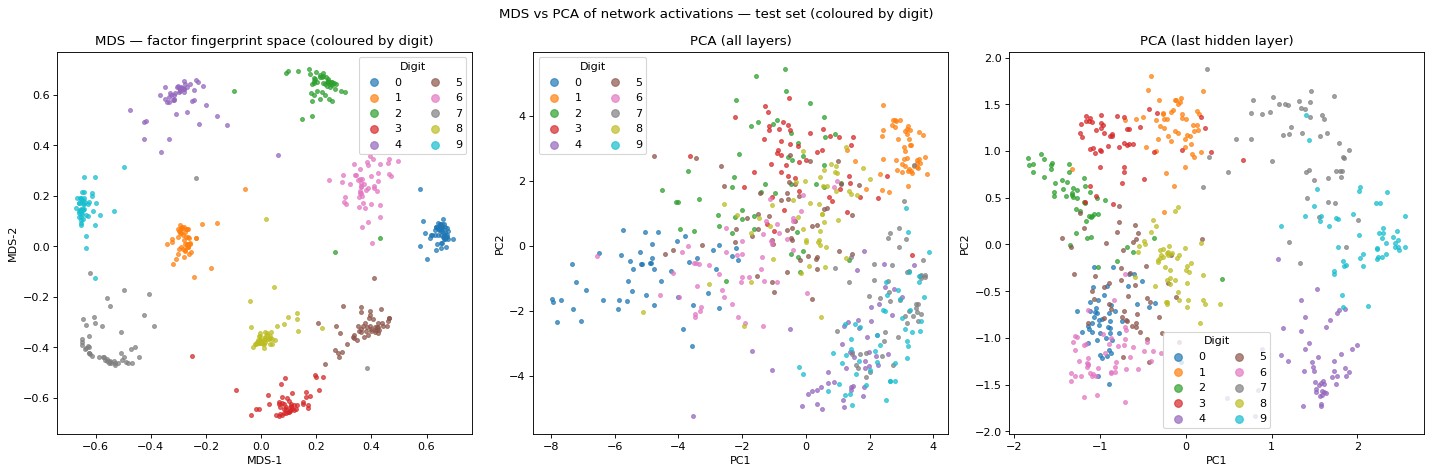

In [9]:
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_distances
from sklearn.decomposition import PCA

dist_matrix = cosine_distances(F[viz_idx])
coords = MDS(n_components=2, dissimilarity='precomputed', random_state=0, n_init=4).fit_transform(dist_matrix)

# PCA over neurons — same stimuli as MDS
_li_sub  = np.hstack([l[viz_idx] for l in layer_inputs])
_li_last = layer_inputs[-2][viz_idx]
pca_all  = PCA(n_components=2).fit_transform(_li_sub)
pca_last = PCA(n_components=2).fit_transform(_li_last)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cmap_tab = plt.get_cmap('tab10')

for cl in range(10):
    mask = targets_viz == cl
    axes[0].scatter(coords[mask, 0], coords[mask, 1], c=[cmap_tab(cl)],
                    s=12, alpha=0.7, label=CLASS_NAMES[cl])
axes[0].legend(markerscale=2, title='Digit', ncol=2)
axes[0].set(title='MDS — factor fingerprint space (coloured by digit)', xlabel='MDS-1', ylabel='MDS-2')

for cl in range(10):
    mask = targets_viz == cl
    axes[1].scatter(pca_all[mask, 0], pca_all[mask, 1], c=[cmap_tab(cl)],
                    s=12, alpha=0.7, label=CLASS_NAMES[cl])
axes[1].legend(markerscale=2, title='Digit', ncol=2)
axes[1].set(title='PCA (all layers)', xlabel='PC1', ylabel='PC2')

for cl in range(10):
    mask = targets_viz == cl
    axes[2].scatter(pca_last[mask, 0], pca_last[mask, 1], c=[cmap_tab(cl)],
                    s=12, alpha=0.7, label=CLASS_NAMES[cl])
axes[2].legend(markerscale=2, title='Digit', ncol=2)
axes[2].set(title='PCA (last hidden layer)', xlabel='PC1', ylabel='PC2')

plt.suptitle('MDS vs PCA of network activations — test set (coloured by digit)', fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'similarity_mds.png'), dpi=120, bbox_inches='tight')
plt.show()

Intra-class similarity: 0.804 ± 0.132
Inter-class similarity: 0.125 ± 0.139

Per-digit intra-class similarity:
  Digit 0: 0.845 ± 0.077
  Digit 1: 0.875 ± 0.087
  Digit 2: 0.779 ± 0.153
  Digit 3: 0.846 ± 0.075
  Digit 4: 0.767 ± 0.143
  Digit 5: 0.831 ± 0.106
  Digit 6: 0.712 ± 0.126
  Digit 7: 0.717 ± 0.146
  Digit 8: 0.852 ± 0.095
  Digit 9: 0.864 ± 0.110


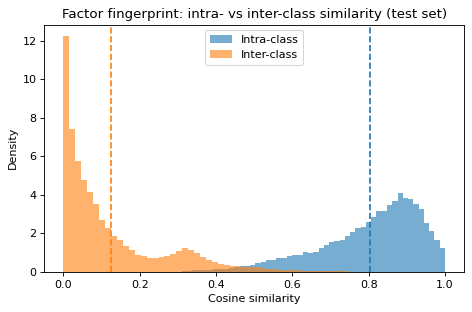

In [10]:
S_all = compute_stimulus_similarity(F)
classes = sorted(np.unique(all_targets))
intra_vals, inter_vals = [], []
for ci, cl in enumerate(classes):
    mask = all_targets == cl
    intra = S_all[np.ix_(mask, mask)]
    intra_vals.extend(intra[np.triu_indices_from(intra, k=1)])
    for cl2 in classes[ci + 1:]:
        inter_vals.extend(S_all[np.ix_(mask, all_targets == cl2)].ravel())

intra_arr, inter_arr = np.array(intra_vals), np.array(inter_vals)
print(f'Intra-class similarity: {intra_arr.mean():.3f} ± {intra_arr.std():.3f}')
print(f'Inter-class similarity: {inter_arr.mean():.3f} ± {inter_arr.std():.3f}')

# Per-digit intra-class similarity
print('\nPer-digit intra-class similarity:')
for cl in classes:
    mask = all_targets == cl
    intra = S_all[np.ix_(mask, mask)]
    vals  = intra[np.triu_indices_from(intra, k=1)]
    print(f'  Digit {cl}: {vals.mean():.3f} ± {vals.std():.3f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(intra_arr, bins=60, alpha=0.6, label='Intra-class', density=True)
ax.hist(inter_arr, bins=60, alpha=0.6, label='Inter-class', density=True)
ax.axvline(intra_arr.mean(), color='C0', ls='--', lw=1.5)
ax.axvline(inter_arr.mean(), color='C1', ls='--', lw=1.5)
ax.set(xlabel='Cosine similarity', ylabel='Density',
       title='Factor fingerprint: intra- vs inter-class similarity (test set)')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'intra_inter_stats.png'), dpi=120, bbox_inches='tight')
plt.show()

## Section 4: ID Sanity Check

Project **training** samples (all 10 MNIST digits — same distribution as BFT) onto the
fixed factors via NNLS and compare their tree activation patterns to **test** samples.
If the factors are stable across train/test, patterns should be nearly identical.

In [11]:
# Collect training layer inputs (correctly classified; cap at 500/class for speed)
data_train = collect_layer_inputs(
    model, train_loader.dataset,
    label_transform=label_transform, n_per_class=500, device=device,
)
idx = np.random.choice(len(data_train['images']), 1000, replace=False)
train_images  = data_train['images'][idx]
train_targets = data_train['targets'][idx]
train_digits  = data_train['digits'][idx]
train_inputs  = [layer[idx] for layer in data_train['layer_inputs']]
print(f'Training samples: {len(train_images)}')
print(f'Class dist: {dict(zip(*np.unique(train_targets, return_counts=True)))}')

Training samples: 1000
Class dist: {np.int64(0): np.int64(114), np.int64(1): np.int64(92), np.int64(2): np.int64(97), np.int64(3): np.int64(97), np.int64(4): np.int64(102), np.int64(5): np.int64(89), np.int64(6): np.int64(105), np.int64(7): np.int64(99), np.int64(8): np.int64(98), np.int64(9): np.int64(107)}


In [12]:
projected_train_root  = project_stimuli_onto_tree(tree_root, train_inputs)
factor_nodes_train    = extract_factor_tree_nodes(projected_train_root)

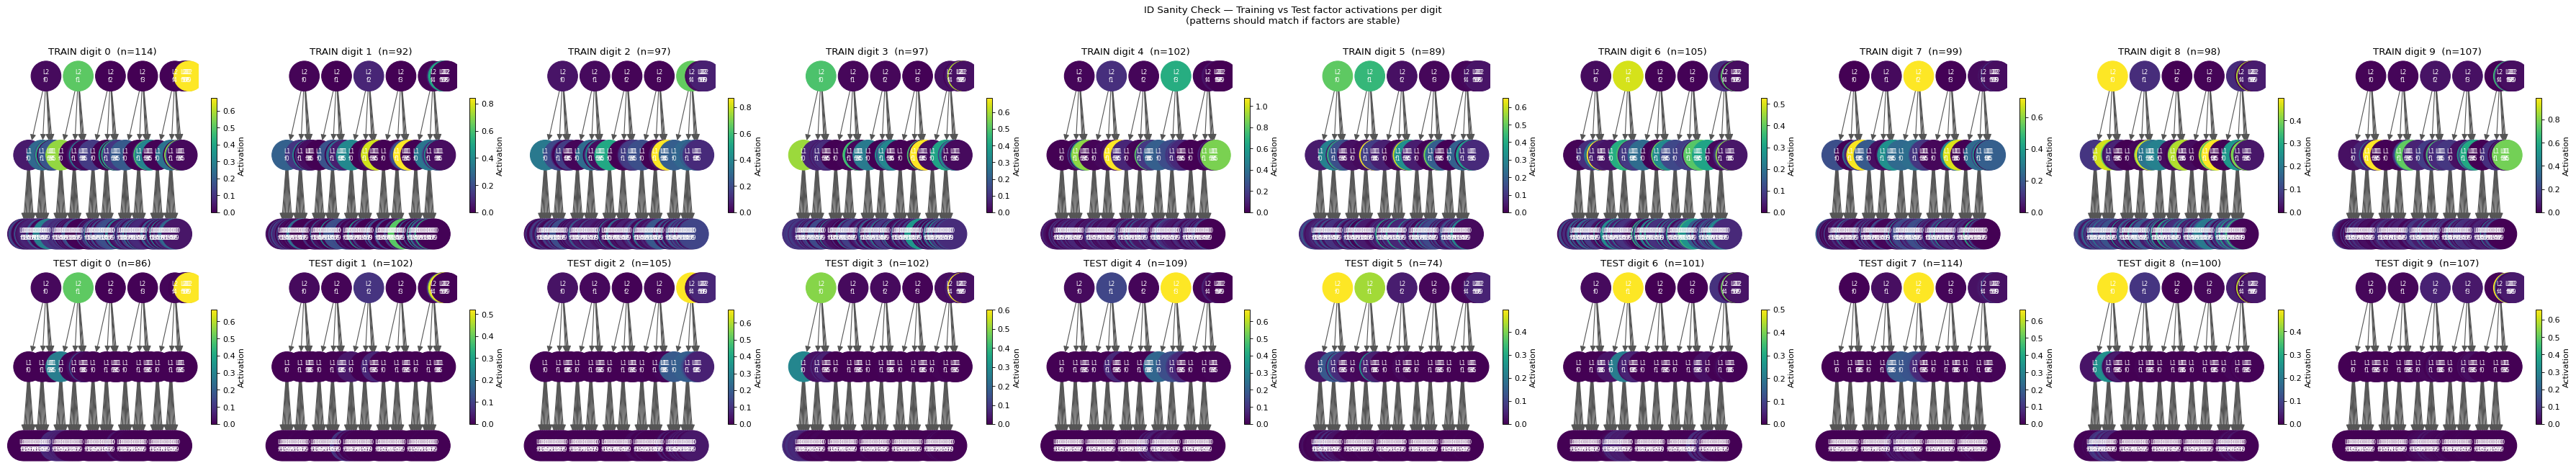

In [13]:
# Side-by-side tree per digit class: training vs test
n_classes = len(classes)
fig, axes = plt.subplots(2, n_classes, figsize=(4.5 * n_classes, 8))

for col, cl in enumerate(classes):
    cl_name = CLASS_NAMES[cl]

    train_cl_idx = np.where(train_targets == cl)[0]
    acts_train = compute_factor_activations(factor_nodes_train, train_cl_idx)
    plot_factor_tree(factor_nodes_train, acts_train, ax=axes[0, col],
                     title=f'TRAIN digit {cl_name}  (n={len(train_cl_idx)})')

    test_cl_idx = np.where(all_targets == cl)[0]
    acts_test = compute_factor_activations(factor_nodes, test_cl_idx)
    plot_factor_tree(factor_nodes, acts_test, ax=axes[1, col],
                     title=f'TEST digit {cl_name}  (n={len(test_cl_idx)})')

plt.suptitle('ID Sanity Check — Training vs Test factor activations per digit\n'
             '(patterns should match if factors are stable)', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'id_tree_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()

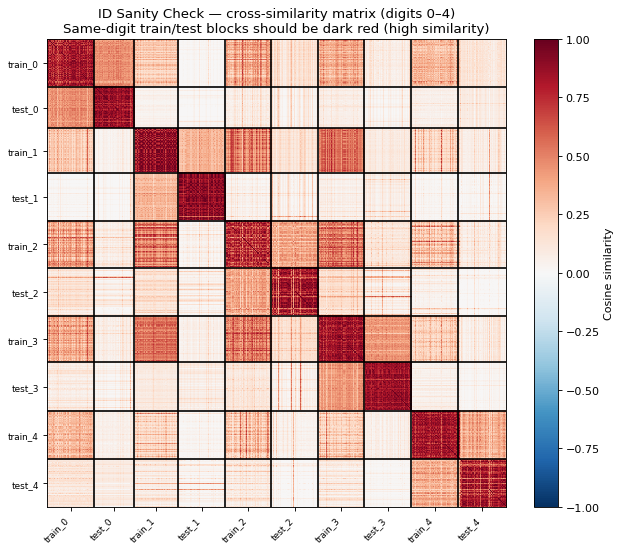

Mean cosine similarity per block pair:
                         train_0          test_0         train_1          test_1         train_2          test_2         train_3          test_3         train_4          test_4
         train_0           0.791           0.456           0.271           0.023           0.393           0.156           0.385           0.089           0.329           0.130
          test_0           0.456           0.845           0.049           0.024           0.094           0.081           0.084           0.049           0.061           0.089
         train_1           0.271           0.049           0.859           0.329           0.525           0.153           0.558           0.100           0.220           0.102
          test_1           0.023           0.024           0.329           0.874           0.056           0.073           0.068           0.089           0.031           0.050
         train_2           0.393           0.094           0.525           0

In [14]:
# Cross-similarity matrix: 3 representative digits (train + test)
N_PER_SPLIT = 100
rng = np.random.default_rng(0)
SHOW_DIGITS = [0, 1, 2, 3, 4]  # show first 5 digits for a readable heatmap

splits = {}
for cl in SHOW_DIGITS:
    cl_name = CLASS_NAMES[cl]
    tr_idx = np.where(train_targets == cl)[0]
    if len(tr_idx) > N_PER_SPLIT:
        tr_idx = rng.choice(tr_idx, N_PER_SPLIT, replace=False)
    splits[f'train_{cl_name}'] = extract_fingerprint_matrix(projected_train_root, tr_idx)

    te_idx = np.where(all_targets == cl)[0]
    if len(te_idx) > N_PER_SPLIT:
        te_idx = rng.choice(te_idx, N_PER_SPLIT, replace=False)
    splits[f'test_{cl_name}'] = extract_fingerprint_matrix(tree_root, te_idx)

split_labels = list(splits.keys())
F_blocks     = np.concatenate(list(splits.values()), axis=0)
block_sizes  = [len(v) for v in splits.values()]
block_starts = [0] + list(np.cumsum(block_sizes[:-1]))
block_ends   = list(np.cumsum(block_sizes))
boundaries   = np.array(block_ends[:-1])
S_cross      = compute_stimulus_similarity(F_blocks)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(S_cross, aspect='auto', interpolation='nearest', cmap='RdBu_r', vmin=-1, vmax=1)
fig.colorbar(im, ax=ax, label='Cosine similarity')

for b in boundaries:
    ax.axhline(b - 0.5, color='k', lw=1.5)
    ax.axvline(b - 0.5, color='k', lw=1.5)

centres = np.array(block_starts) + np.array(block_sizes) / 2
ax.set_xticks(centres); ax.set_xticklabels(split_labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(centres); ax.set_yticklabels(split_labels, fontsize=8)
ax.set_title('ID Sanity Check — cross-similarity matrix (digits 0–4)\n'
             'Same-digit train/test blocks should be dark red (high similarity)')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'id_fingerprint_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()

print('Mean cosine similarity per block pair:')
header = ''.join(f'{l:>16}' for l in split_labels)
print(f'{"":>16}{header}')
for i, li in enumerate(split_labels):
    row_vals = []
    for j, lj in enumerate(split_labels):
        block = S_cross[block_starts[i]:block_ends[i], block_starts[j]:block_ends[j]]
        vals  = block[np.triu_indices_from(block, k=1)] if i == j else block.ravel()
        row_vals.append(f'{vals.mean():>16.3f}')
    print(f'{li:>16}' + ''.join(row_vals))

/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


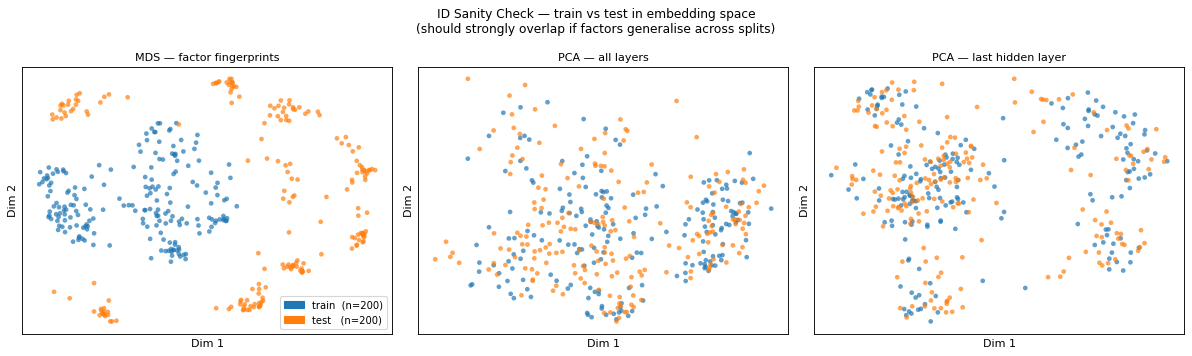

In [15]:
# ── MDS + PCA: training vs test colored by split (ID sanity check) ────────────
N_SAMPLE_ID = 200
rng_id = np.random.default_rng(42)

n_train_id = len(train_images)
tr_sub = rng_id.choice(n_train_id, min(N_SAMPLE_ID, n_train_id), replace=False)
te_sub = rng_id.choice(n_samples,  min(N_SAMPLE_ID, n_samples),  replace=False)
n_tr, n_te = len(tr_sub), len(te_sub)

# Factor fingerprints (train projected, test from original tree)
F_tr    = extract_fingerprint_matrix(projected_train_root, tr_sub)
F_te    = extract_fingerprint_matrix(tree_root, te_sub)
F_joint = np.concatenate([F_tr, F_te], axis=0)

# MDS on fingerprint cosine distances
coords_mds_id = MDS(n_components=2, dissimilarity='precomputed',
                    random_state=0, n_init=4).fit_transform(cosine_distances(F_joint))

# PCA on raw layer activations (all layers concatenated)
li_joint_all = np.concatenate([
    np.hstack([l[tr_sub] for l in train_inputs]),
    np.hstack([l[te_sub] for l in layer_inputs]),
], axis=0)
pca_all_id = PCA(n_components=2).fit_transform(li_joint_all)

# PCA on last hidden layer only
li_joint_last = np.concatenate([train_inputs[-2][tr_sub], layer_inputs[-2][te_sub]], axis=0)
pca_last_id   = PCA(n_components=2).fit_transform(li_joint_last)

# Plot — blue = train, orange = test
colors = ['#1f77b4'] * n_tr + ['#ff7f0e'] * n_te
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color='#1f77b4', label=f'train  (n={n_tr})'),
    mpatches.Patch(color='#ff7f0e', label=f'test   (n={n_te})'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, coords, title in zip(
    axes,
    [coords_mds_id, pca_all_id, pca_last_id],
    ['MDS — factor fingerprints', 'PCA — all layers', 'PCA — last hidden layer'],
):
    ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=18, alpha=0.7, linewidths=0)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
    ax.set_xticks([]); ax.set_yticks([])

axes[0].legend(handles=legend_handles, loc='best', fontsize=9)
plt.suptitle('ID Sanity Check — train vs test in embedding space\n'
             '(should strongly overlap if factors generalise across splits)', fontsize=11)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'id_mds_pca_train_vs_test.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 5: Real OOD — Fashion-MNIST

The digit MLP was trained on **all 10 MNIST digits** — there are no excluded training digits
to serve as near-OOD.  Instead we use **Fashion-MNIST** (FashionMNIST): 10,000 test images
of clothing items, also 28×28 grayscale.  The model has never seen fashion items; they
represent a true **domain shift** (different textures, shapes, and statistics).

Fashion-MNIST classes (0–9): T-shirt/top, Trouser, Pullover, Dress, Coat,
Sandal, Shirt, Sneaker, Bag, Ankle boot.

In [16]:
fmnist_test = datasets.FashionMNIST('../data/', train=False, download=True, transform=ToTensor())

data_ood = collect_layer_inputs_generic(
    model, fmnist_test,
    label_transform=label_transform,
    only_correct=False, device=device,
)

idx = np.random.choice(len(data_ood['images']), 1000)
ood_images  = data_ood['images'][idx]       # (N, 1, 28, 28)
ood_digits  = data_ood['digits'][idx]        # FMNIST class labels (0=T-shirt, ...)
ood_targets = data_ood['targets'][idx]      # same (identity transform)
ood_preds   = data_ood['preds'][idx]         # which MNIST digit the model predicts
ood_inputs  = [layer[idx] for layer in data_ood['layer_inputs']]

n_ood = len(ood_images)
# 'accuracy' here means: does the predicted digit class coincide with the FMNIST class number?
# (meaningless, reported only as a sanity check — should be ~10%)
ood_acc = (ood_preds == ood_targets).mean()
print(f'Fashion-MNIST samples   : {n_ood}')
print(f'Model accuracy on FMNIST: {ood_acc:.3f}  (chance = 0.1)')
print(f'FMNIST class breakdown  : {dict(zip(*np.unique(ood_digits, return_counts=True)))}')
print()
print('Digit predictions for each FMNIST class:')
for fc in range(10):
    mask = ood_digits == fc
    pred_dist = dict(zip(*np.unique(ood_preds[mask], return_counts=True)))
    print(f'  {FMNIST_CLASSES[fc]:15s}: {pred_dist}')

Fashion-MNIST samples   : 1000
Model accuracy on FMNIST: 0.128  (chance = 0.1)
FMNIST class breakdown  : {np.int64(0): np.int64(118), np.int64(1): np.int64(92), np.int64(2): np.int64(97), np.int64(3): np.int64(84), np.int64(4): np.int64(111), np.int64(5): np.int64(111), np.int64(6): np.int64(103), np.int64(7): np.int64(107), np.int64(8): np.int64(90), np.int64(9): np.int64(87)}

Digit predictions for each FMNIST class:
  T-shirt/top    : {np.int64(0): np.int64(22), np.int64(2): np.int64(13), np.int64(3): np.int64(16), np.int64(4): np.int64(2), np.int64(5): np.int64(61), np.int64(6): np.int64(3), np.int64(8): np.int64(1)}
  Trouser        : {np.int64(0): np.int64(4), np.int64(2): np.int64(57), np.int64(3): np.int64(21), np.int64(5): np.int64(8), np.int64(6): np.int64(2)}
  Pullover       : {np.int64(0): np.int64(3), np.int64(2): np.int64(58), np.int64(3): np.int64(5), np.int64(5): np.int64(23), np.int64(6): np.int64(8)}
  Dress          : {np.int64(0): np.int64(2), np.int64(2): np.int64

In [17]:
projected_ood_root  = project_stimuli_onto_tree(tree_root, ood_inputs)
factor_nodes_ood    = extract_factor_tree_nodes(projected_ood_root)

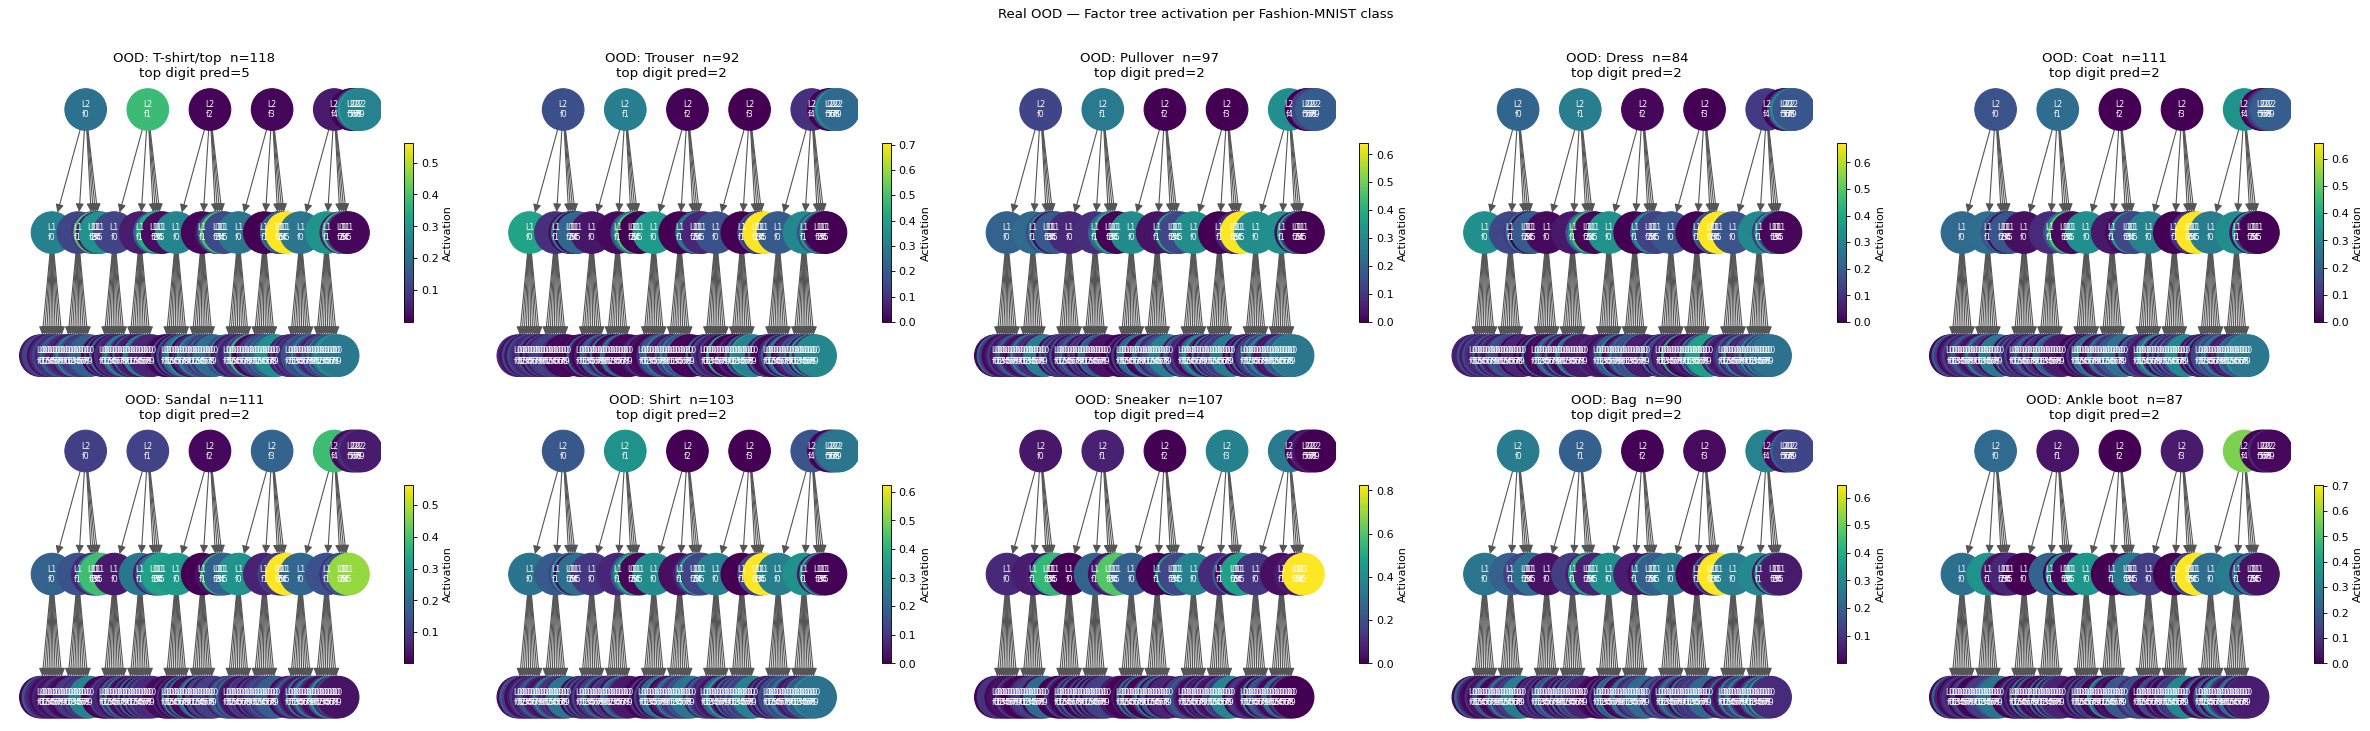

In [18]:
# ── Tree per Fashion-MNIST class ───────────────────────────────────────────────
unique_fmnist = sorted(np.unique(ood_digits))
ncols = min(5, len(unique_fmnist))
nrows = int(np.ceil(len(unique_fmnist) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)

for i, fc in enumerate(unique_fmnist):
    ax = axes[i // ncols][i % ncols]
    fc_idx = np.where(ood_digits == fc)[0]
    acts = compute_factor_activations(factor_nodes_ood, fc_idx)
    top_pred = np.bincount(ood_preds[fc_idx]).argmax()
    plot_factor_tree(
        factor_nodes_ood, acts, ax=ax,
        title=f'OOD: {FMNIST_CLASSES[fc]}  n={len(fc_idx)}\ntop digit pred={top_pred}',
    )

for j in range(len(unique_fmnist), nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)

plt.suptitle('Real OOD — Factor tree activation per Fashion-MNIST class', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'ood_tree_per_fmnist_class.png'), dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── MDS + PCA: ID test vs Fashion-MNIST OOD in factor space ──────────────────
N_ID_SAMPLE  = 200
N_OOD_SAMPLE = min(200, n_ood)

rng = np.random.default_rng(1)
id_sub   = rng.choice(n_samples, N_ID_SAMPLE, replace=False)
ood_sub  = rng.choice(n_ood,     N_OOD_SAMPLE, replace=False)

F_id      = extract_fingerprint_matrix(tree_root, id_sub)
F_ood_sub = extract_fingerprint_matrix(projected_ood_root, ood_sub)
F_joint   = np.concatenate([F_id, F_ood_sub], axis=0)

coords = MDS(n_components=2, dissimilarity='precomputed', random_state=0, n_init=4).fit_transform(
    cosine_distances(F_joint)
)

# PCA over neurons for the same joint stimulus set
_li_id   = np.hstack([l[id_sub]  for l in layer_inputs])
_li_ood  = np.hstack([l[ood_sub] for l in ood_inputs])
_li_joint_all  = np.vstack([_li_id,  _li_ood])
_li_joint_last = np.vstack([layer_inputs[-2][id_sub], ood_inputs[-2][ood_sub]])
pca_all  = PCA(n_components=2).fit_transform(_li_joint_all)
pca_last = PCA(n_components=2).fit_transform(_li_joint_last)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
cmap_tab = plt.get_cmap('tab10')

# MDS: ID vs OOD colouring
axes[0].scatter(coords[:N_ID_SAMPLE, 0], coords[:N_ID_SAMPLE, 1],
                c='steelblue', s=10, alpha=0.6, label='ID test (MNIST digits)')
axes[0].scatter(coords[N_ID_SAMPLE:, 0], coords[N_ID_SAMPLE:, 1],
                c='tomato',    s=10, alpha=0.6, label='OOD (Fashion-MNIST)')
axes[0].legend(markerscale=3)
axes[0].set(title='MDS — MNIST digits vs Fashion-MNIST', xlabel='MDS-1', ylabel='MDS-2')

# PCA — all layers, ID/OOD colouring
axes[1].scatter(pca_all[:N_ID_SAMPLE, 0], pca_all[:N_ID_SAMPLE, 1],
                c='steelblue', s=10, alpha=0.6, label='ID test (MNIST)')
axes[1].scatter(pca_all[N_ID_SAMPLE:, 0], pca_all[N_ID_SAMPLE:, 1],
                c='tomato',    s=10, alpha=0.6, label='OOD (FashionMNIST)')
axes[1].legend(markerscale=3)
axes[1].set(title='PCA (all layers) — ID vs OOD', xlabel='PC1', ylabel='PC2')

# PCA — last hidden layer, ID/OOD colouring
axes[2].scatter(pca_last[:N_ID_SAMPLE, 0], pca_last[:N_ID_SAMPLE, 1],
                c='steelblue', s=10, alpha=0.6, label='ID test (MNIST)')
axes[2].scatter(pca_last[N_ID_SAMPLE:, 0], pca_last[N_ID_SAMPLE:, 1],
                c='tomato',    s=10, alpha=0.6, label='OOD (FashionMNIST)')
axes[2].legend(markerscale=3)
axes[2].set(title='PCA (last hidden layer) — ID vs OOD', xlabel='PC1', ylabel='PC2')


#                            min(N_BLOCK, (all_targets == cl).sum()), replace=False)
#    blocks[f'ID-{cl}'] = extract_fingerprint_matrix(tree_root, idx)

for fc in BLOCK_FMNIST:
    idx = rng_block.choice(np.where(ood_digits == fc)[0],
                            min(N_BLOCK, (ood_digits == fc).sum()), replace=False)
    blocks[f'FM-{FMNIST_CLASSES[fc][:6]}'] = extract_fingerprint_matrix(projected_ood_root, idx)

block_labels  = list(blocks.keys())
F_all_blocks  = np.concatenate(list(blocks.values()), axis=0)
bl_sizes      = [len(v) for v in blocks.values()]
bl_starts     = [0] + list(np.cumsum(bl_sizes[:-1]))
bl_ends       = list(np.cumsum(bl_sizes))
bounds        = np.array(bl_ends[:-1])
S_blocks      = compute_stimulus_similarity(F_all_blocks)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(S_blocks, aspect='auto', interpolation='nearest', cmap='RdBu_r', vmin=-1, vmax=1)
fig.colorbar(im, ax=ax, label='Cosine similarity')
for b in bounds:
    ax.axhline(b - 0.5, color='k', lw=1.5)
    ax.axvline(b - 0.5, color='k', lw=1.5)
centres = np.array(bl_starts) + np.array(bl_sizes) / 2
ax.set_xticks(centres); ax.set_xticklabels(block_labels, rotation=35, ha='right')
ax.set_yticks(centres); ax.set_yticklabels(block_labels)
ax.set_title('ID digits vs OOD Fashion-MNIST fingerprint cross-similarity\n'
             'Low off-diagonal (ID ↔ OOD) = factor space is domain-specific')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'ood_cross_similarity.png'), dpi=120, bbox_inches='tight')
plt.show()

IndentationError: unexpected indent (1635890552.py, line 39)

## Section 5b: Far OOD — Synthetic images with no digit structure

Four synthetic image types:
- **gaussian_noise** — i.i.d. pixels ~ N(0.5, 0.25²), clipped to [0, 1]
- **uniform_gray** — constant mid-grey (all pixels = 0.5)
- **checkerboard** — hard 0/1 alternating pattern at pixel scale
- **inverted_test** — 1 − (test digit image): same structure, opposite contrast

In [ ]:
N_FAR = 300
rng_f = np.random.default_rng(99)

_chk = (np.indices((IMAGE_SIDE, IMAGE_SIDE)).sum(axis=0) % 2).astype(np.float32)

far_ood_arrays = {
    'gaussian_noise': np.clip(
        rng_f.normal(0.5, 0.25, (N_FAR, 1, IMAGE_SIDE, IMAGE_SIDE)).astype(np.float32), 0, 1),
    'uniform_gray':   np.full((N_FAR, 1, IMAGE_SIDE, IMAGE_SIDE), 0.5, dtype=np.float32),
    'checkerboard':   np.broadcast_to(_chk, (N_FAR, 1, IMAGE_SIDE, IMAGE_SIDE)).copy().astype(np.float32),
    'inverted_test':  np.clip(1.0 - all_images[:N_FAR], 0, 1).astype(np.float32),
}

def collect_far_ood(model, images_np, label_transform, device, batch_size=256):
    dataset = TensorDataset(
        torch.from_numpy(images_np),
        torch.zeros(len(images_np), dtype=torch.long),
    )
    return collect_layer_inputs_generic(
        model, dataset, label_transform=label_transform,
        only_correct=False, device=device, batch_size=batch_size,
    )

far_ood_data = {}
for name, imgs in far_ood_arrays.items():
    d = collect_far_ood(model, imgs, label_transform, device)
    d['projected_root'] = project_stimuli_onto_tree(tree_root, d['layer_inputs'])
    d['factor_nodes']   = extract_factor_tree_nodes(d['projected_root'])
    far_ood_data[name] = d
    acc = (d['preds'] == d['targets']).mean()
    print(f'{name:20s}  n={len(imgs)}  model acc={acc:.3f}')

gaussian_noise        n=300  model acc=0.000
uniform_gray          n=300  model acc=0.000
checkerboard          n=300  model acc=0.000
inverted_test         n=300  model acc=0.090


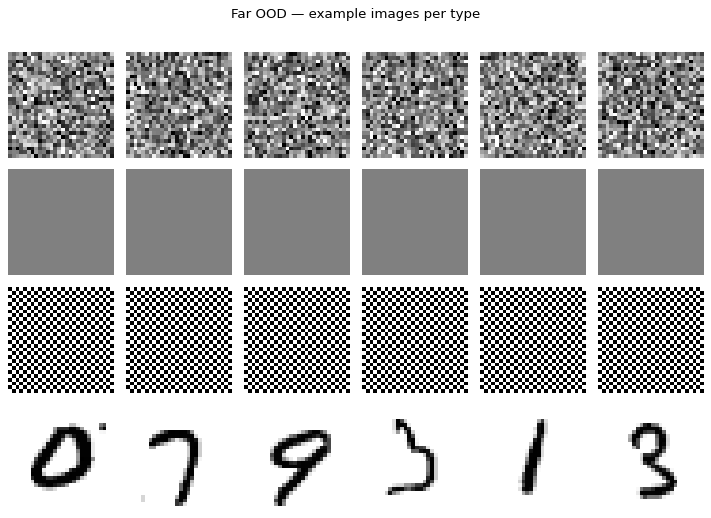

In [ ]:
n_examples = 6
fig, axes = plt.subplots(len(far_ood_arrays), n_examples,
                          figsize=(n_examples * 1.5, len(far_ood_arrays) * 1.6))
for row, (name, imgs) in enumerate(far_ood_arrays.items()):
    for col in range(n_examples):
        axes[row, col].imshow(imgs[col, 0], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(name, fontsize=9, rotation=30, ha='right', va='center')
plt.suptitle('Far OOD — example images per type', y=1.01, fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'far_ood_examples.png'), dpi=120, bbox_inches='tight')
plt.show()

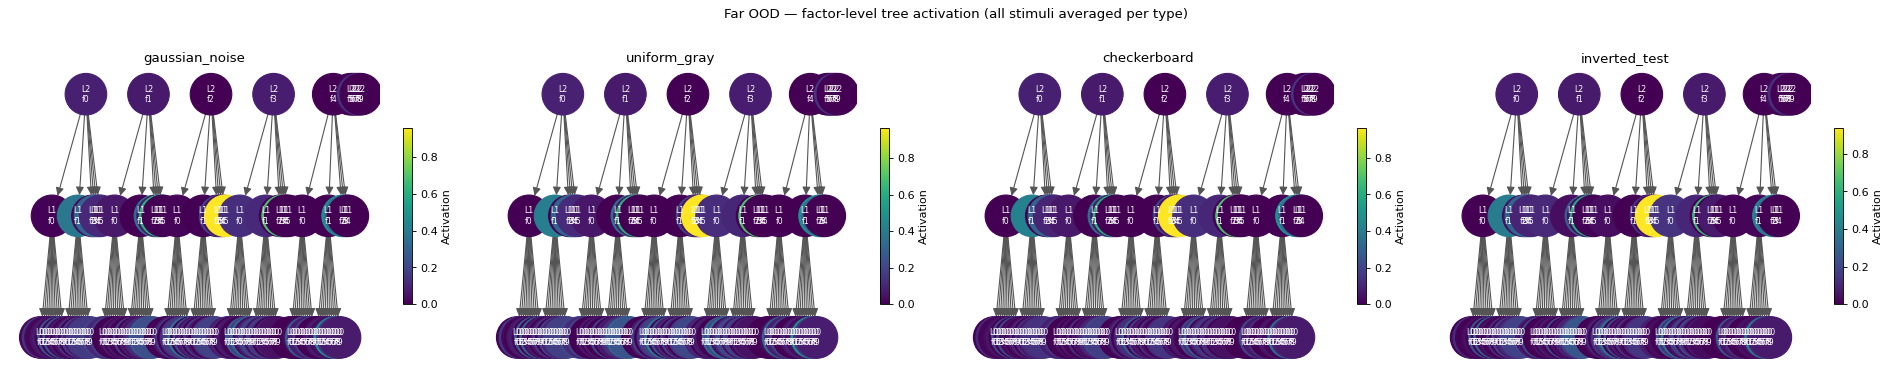

In [ ]:
n_types = len(far_ood_data)
fig, axes = plt.subplots(1, n_types, figsize=(6 * n_types, 4.5), squeeze=False)
axes = axes[0]

for ax, (name, d) in zip(axes, far_ood_data.items()):
    all_idx = np.arange(len(d['images']))
    acts    = compute_factor_activations(d['factor_nodes'], all_idx)
    plot_factor_tree(d['factor_nodes'], acts, ax=ax, title=name)

plt.suptitle('Far OOD — factor-level tree activation (all stimuli averaged per type)',
             y=1.02, fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'far_ood_factor_tree.png'), dpi=120, bbox_inches='tight')
plt.show()

/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


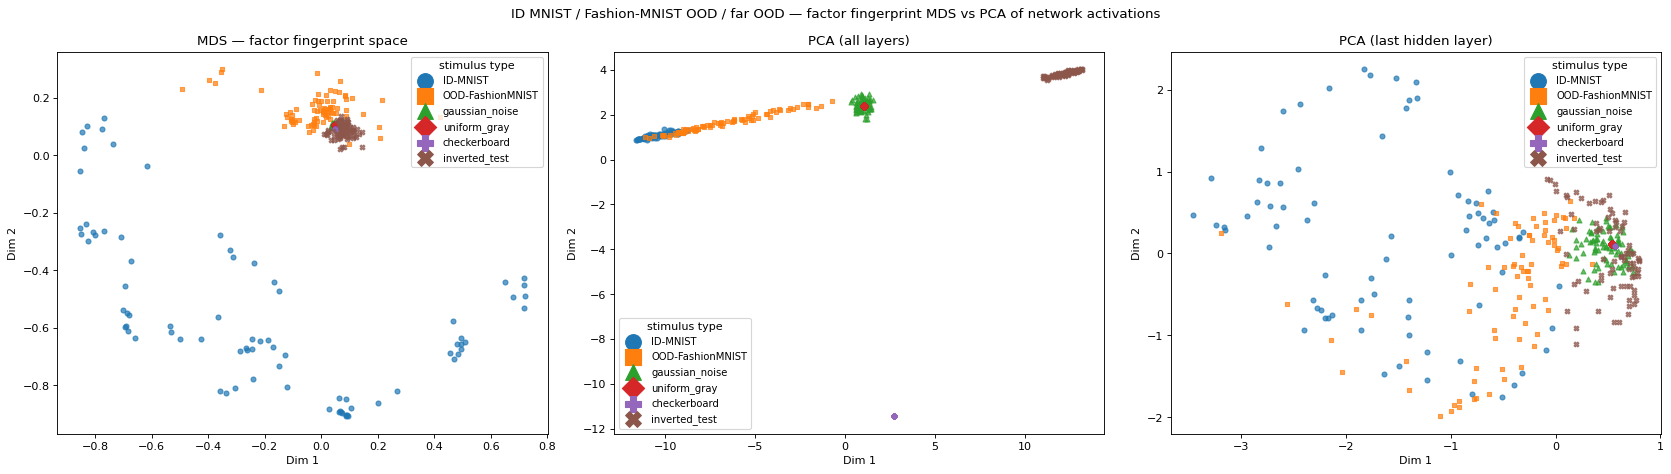

In [ ]:
# ── MDS + PCA: ID test / Fashion-MNIST OOD / far OOD in factor fingerprint space ──
N_EACH_MDS = 80
rng_m = np.random.default_rng(7)

F_parts, li_all_parts, li_last_parts = [], [], []
mds_labels, mds_markers = [], []

# ID test
id_sub = rng_m.choice(n_samples, min(N_EACH_MDS, n_samples), replace=False)
F_parts.append(extract_fingerprint_matrix(tree_root, id_sub))
li_all_parts.append(np.hstack([l[id_sub] for l in layer_inputs]))
li_last_parts.append(layer_inputs[-2][id_sub])
mds_labels  += ['ID-MNIST'] * len(id_sub)
mds_markers += ['o'] * len(id_sub)

# Fashion-MNIST OOD
ood_sub = rng_m.choice(n_ood, min(N_EACH_MDS, n_ood), replace=False)
F_parts.append(extract_fingerprint_matrix(projected_ood_root, ood_sub))
li_all_parts.append(np.hstack([l[ood_sub] for l in ood_inputs]))
li_last_parts.append(ood_inputs[-2][ood_sub])
mds_labels  += ['OOD-FashionMNIST'] * len(ood_sub)
mds_markers += ['s'] * len(ood_sub)

# Far OOD types
marker_cycle = ['^', 'D', 'P', 'X']
for (name, d), mkr in zip(far_ood_data.items(), marker_cycle):
    n = min(N_EACH_MDS, len(d['images']))
    sub = rng_m.choice(len(d['images']), n, replace=False)
    F_parts.append(extract_fingerprint_matrix(d['projected_root'], sub))
    li_all_parts.append(np.hstack([l[sub] for l in d['layer_inputs']]))
    li_last_parts.append(d['layer_inputs'][-2][sub])
    mds_labels  += [name] * n
    mds_markers += [mkr] * n

F_joint    = np.concatenate(F_parts, axis=0)
coords_mds = MDS(n_components=2, dissimilarity='precomputed',
                 random_state=0, n_init=4).fit_transform(cosine_distances(F_joint))
pca_all  = PCA(n_components=2).fit_transform(np.vstack(li_all_parts))
pca_last = PCA(n_components=2).fit_transform(np.vstack(li_last_parts))

unique_labels = list(dict.fromkeys(mds_labels))
cmap_tab = plt.get_cmap('tab10')
label_color  = {l: cmap_tab(i % 10) for i, l in enumerate(unique_labels)}
label_marker = dict(zip(mds_labels, mds_markers))

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for embed, ax, title in [
    (coords_mds, axes[0], 'MDS — factor fingerprint space'),
    (pca_all,    axes[1], 'PCA (all layers)'),
    (pca_last,   axes[2], 'PCA (last hidden layer)'),
]:
    for i, lbl in enumerate(mds_labels):
        ax.scatter(embed[i, 0], embed[i, 1],
                   c=[label_color[lbl]], marker=label_marker[lbl], s=20, alpha=0.7)
    for lbl in unique_labels:
        ax.scatter([], [], c=[label_color[lbl]], marker=label_marker[lbl], s=50, label=lbl)
    ax.legend(markerscale=2, ncol=1, fontsize=9, title='stimulus type')
    ax.set(title=title, xlabel='Dim 1', ylabel='Dim 2')

plt.suptitle('ID MNIST / Fashion-MNIST OOD / far OOD — factor fingerprint MDS vs PCA of network activations',
             fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'far_ood_mds.png'), dpi=120, bbox_inches='tight')
plt.show()